# Agents是什么？

Agent将模型与工具结合，能够够推理任务、决定使用哪些工具，并迭代地工作以寻求解决方案

Langchain1.x中将所有创建Agent的接口统一到 `create_agent` API


In [2]:
from langchain_openai import ChatOpenAI
import os
def get_model():
    """获取聊天模型实例"""
    return ChatOpenAI(
        model="Qwen/Qwen2.5-7B-Instruct",
        base_url="https://api.siliconflow.cn/v1",
        api_key=os.environ.get("SILICONFLOW_API_KEY"),
        temperature=0.2,
    )
llm = get_model()
llm

ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000025A01A678C0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000025A01F98590>, root_client=<openai.OpenAI object at 0x0000025A01946A50>, root_async_client=<openai.AsyncOpenAI object at 0x0000025A01F982F0>, model_name='Qwen/Qwen2.5-7B-Instruct', temperature=0.2, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://api.siliconflow.cn/v1')

# core components 核心组件

## model模型
模型是Agent的推理引擎，可以通过动态和静态的方式指定

可以动态选择模型，通过middleware来实现，`wrap_model_call` 


### static model
在创建Agent的时候配置一次，运行过程中不改变


### dynamic model
动态模型是在 **运行时（runtime）** 基于当前的 **状态（state）** 还有 **上下文（context）** 来选择模型；这使得能够实现复杂的路由逻辑和成本优化。


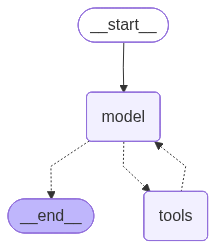

In [3]:
# agent 
from langchain.agents import create_agent 
# middleware
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
# tools
from langchain.tools import tool


basic_model = llm
pro_model = ChatOpenAI(
    model="Qwen/Qwen2.5-7B-Instruct",
        base_url="https://api.siliconflow.cn/v1",
        api_key=os.environ.get("SILICONFLOW_API_KEY"),
        temperature=0.5,
)
@tool(name_or_callable='hi')
def mytool(name: str) -> str:
    "打招呼函数" 
    # doc-string 是必要的描述，要不然Agent不知道要什么时候用和怎么用
    return f"你好{name}"

# 装饰器
@wrap_model_call
def dynamic_model_selection(request: ModelRequest, handler) -> ModelResponse:
    """根据当前的状态和上下文来选择模型"""
    # request就是这一次请求的信息
    # handler是指向后续处理链的“传递带”
    message_count = len(request.state["messages"])
    
    if message_count > 10:
        # Use an advanced model for longer conversations
        model = pro_model
    else:
        model = basic_model
        
    # 去修改这一次的请求信息, 使用handler来传递
    return handler(request.override(model=model))
    """request.override() 的 args
    - `model`: `BaseChatModel` instance
    - `system_prompt`: deprecated, use `system_message` instead
    - `system_message`: `SystemMessage` instance
    - `messages`: `list` of messages
    - `tool_choice`: Tool choice configuration
    - `tools`: `list` of available tools
    - `response_format`: Response format specification
    - `model_settings`: Additional model settings
    - `state`: Agent state dictionary
    """

agent = create_agent(
    model = basic_model,
    tools=[mytool],
    middleware=[dynamic_model_selection]
)

agent

#### ModelRequest & ModelResponse

- ModelRequest封装了一次模型调用**请求信息**，包含了当前Agent运行时的所有上下文
  - state：Agent当前的状态，历史消息、自定义状态字段
  - message：本次调用需要处理的聊天信息列表
  - tools：当前可用的工具列表
  - runtime：运行时上下文，用户角色、权限
  - model：当前配置的模型实例

#### 为什么要handler？
handler是中间件系统的核心设计，handler是一个**可调用对象**（函数），代表 **中间件链中的下一个处理环节**。当调用`handler(request)`时，请求会继续传递到：
1. 下一个中间件
2. 最终到达实际的模型调用

`handler`是中间件系统的"接力棒"：

- 它连接了各个中间件，形成处理链
- 让每个中间件专注于自己的逻辑
- 提供了极大的灵活性（修改、短路、重试等）
- 是责任链模式（Chain of Responsibility）的经典实现



### Tools
有静态工具和动态工具两种模式，静态工具在创建Agent的时候就把所有Tools注册给Agent，动态工具是在runtime进行修改，工具过多可能会使模型过载（上下文过载）并增加错误，因为每一个模型都是一个提示词（doc-string）。

动态工具选择能够根据认证状态、用户权限、功能标志或对话阶段来调整可用工具集

#### 两种方法控制动态工具
根据工具是否提前被Agent知晓分区出两种：
1. 过滤预注册工具
   - 当在代理创建时所有可能的工具都已知晓时，您可以预先注册它们，并根据状态、权限或上下文动态过滤哪些工具**暴露**给模型。
2. 运行时工具注册
   - 当工具在运行时被发现或创建（例如，从 MCP 服务器加载、根据用户数据生成或从远程注册表获取）时，您需要同时注册这些工具并动态处理它们的执行。



#### 过滤预注册工具
Filtering pre-registered tools
也就是先把工具都注册到Agent中，然后通过一些控制代码，再根据当前的状态和上下文来把Tools暴露给Agent
- 状态
- 权限
- 上下文

In [4]:
# 按照State -> 状态来控制

from langchain.agents.middleware import wrap_tool_call, ModelRequest, ModelResponse
from typing import Callable # 1. Callable是什么？

@wrap_model_call # 这里是在调用模型之中的要控制Tools
def state_based_tools(
    request: ModelRequest, # 封装模型的一次请求类
    handler: Callable[[ModelRequest], ModelResponse] # Callable对象
    # 第一个参数是传入的参数列表类型，后一个是返回值类型
) -> ModelResponse:
    """按照当前的对话情况过滤Tools"""
    # Read from State: check if user has authenticated
    # 使用dict的安全取值get方法, get("要取的值", 默认值)
    # 这样就不会因为没有key而抛出KeyError
    
    state = request.state 
    # print(state)
    # state: AgentState
    is_authenticated = state.get("authenticated", False) # 看一下有无授权
    message_count = len(state["messages"])

    # Only enable sensitive tools after authentication
    if not is_authenticated:
        tools = [t for t in request.tools if t.name.startswith("public_")]
        # 2. startswith 是只选择满足"public_"开头的Tools
        request = request.override(tools=tools) # 重写Tools列表
    elif message_count < 5:
        # Limit tools early in conversation
        tools = [t for t in request.tools if t.name != "advanced_search"]
        request = request.override(tools=tools)

    return handler(request) # 传递处理过的request


##### 什么是store？
langchian的上下文中，Store是一个持久化存储系统

在 LangChain/LangGraph 的上下文中， **Store（存储）** 是一个 **持久化存储系统** ，用于保存和检索数据，特别是在 Agent 应用中管理长期记忆（Long-term Memory） 和向量数据（Vector Data）。

store用于存储key-value的，用在给Agent提供memory记忆的

In [5]:
# 按照Store
from dataclasses import dataclass # 自定义数据结构
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable
# 导入memory的store
from langgraph.store.memory import InMemoryStore # 存在内存中

@dataclass
class Context():
    user_id: str # 自定义数据类型
    
@wrap_model_call
def store_based_tools(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """按照Store来过滤tools."""
    user_id = request.runtime.context.user_id
    # runtime.context 运行时上下文

    # Read from Store: get user's enabled features
    store = request.runtime.store
    feature_flags = store.get(("features",), user_id)

    if feature_flags:
        enabled_features = feature_flags.value.get("enabled_tools", [])
        # Only include tools that are enabled for this user
        tools = [t for t in request.tools if t.name in enabled_features]
        request = request.override(tools=tools)

    return handler(request)


In [6]:
# Runtime Context

from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable

@dataclass
class Context:
    user_role: str # 用户角色

@wrap_model_call
def context_based_tools(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """过滤Tools按照运行时上下文."""
    # Read from Runtime Context: get user role
    if request.runtime is None or request.runtime.context is None:
        # If no context provided, default to viewer (most restrictive)
        user_role = "viewer" 
    else:
        user_role = request.runtime.context.user_role

    if user_role == "admin":
        # Admins get all tools
        pass
    elif user_role == "editor":
        # Editors can't delete
        tools = [t for t in request.tools if t.name != "delete_data"]
        request = request.override(tools=tools)
    else:
        # Viewers get read-only tools
        tools = [t for t in request.tools if t.name.startswith("read_")]
        request = request.override(tools=tools)

    return handler(request)



**[扩展] Runtime 是什么？**

`Runtime Context `为你的 `tools` 和 `middleware` 提供 **依赖注入** 能力。你可以在 `invoke agent` 时注入运行时依赖（如数据库连接、用户 ID、配置信息），而不需要 **硬编码**  或 **使用全局状态** ，让你的代码更易测试和复用。
LangChain 的 create_agent 底层运行在 LangGraph 的 runtime 上，`Runtime` 对象包含三部分信息：
- Context（静态信息如 user_id、db 连接等）、
- Store（用于长期记忆的 BaseStore 实例）、
- 以及 Stream writer（用于 custom 流式输出）

基本用法

通过dataclass的形式定义 context schema（格式），在 invoke 时注入

在 Tool 内访问

在 tool 内使用 `ToolRuntime` 参数来访问 Runtime 对象，可以读取 context、读写长期记忆、或者向 custom stream 写入数据

在 Middleware 内访问

在 `node-style hooks` 中，用 `Runtime` 参数访问 Runtime 对象；在 `wrap-style hooks` 中，Runtime 对象包含在 `ModelRequest` 参数里

In [7]:
# from langgraph.runtime import Runtime # runtime类

### 运行时工具注册
当工具在运行时被发现或创建（例如，从 MCP 服务器加载、根据用户数据生成或从远程注册表获取）时，您需要同时注册这些工具并动态处理它们的执行。

需要两个中间件hooks：
1. wrap_model_call - 将动态工具添加到请求
2. wrap_tool_call - 处理动态添加的工具的 **执行**

In [ ]:
from langchain.tools import tool
from langchain.agents import create_agent
from langchain.agents.middleware import AgentMiddleware, ModelRequest, ToolCallRequest

# tool在runtime时动态添加

model = get_model()

@tool
def calculate_tip(bill_amount: float, tip_percentage: float = 20.0) -> str:
    """从账单中计算小费"""
    tip = bill_amount * (tip_percentage / 100)
    return f"Tip: ${tip:.2f}, Total: ${bill_amount + tip:.2f}"

# 定义一个中间件类，去继承AgentMiddleware类
class DynamicToolMiddleware(AgentMiddleware):
    """Middleware that registers and handles dynamic tools."""

    # 用于动态添加tool的hook
    def wrap_model_call(self, request: ModelRequest, handler):
        # Add dynamic tool to the request
        # This could be loaded from an MCP server, database, etc.
        updated_request = request.override(tools=[*request.tools, calculate_tip])
        # *request.tools 先解包，然后再传入新的
        return handler(updated_request)
    # 用于执行新添加的tool的hook
    def wrap_tool_call(self, request: ToolCallRequest, handler):
        # Handle execution of the dynamic tool
        if request.tool_call["name"] == "calculate_tip":
            return handler(request.override(tool=calculate_tip))
        return handler(request)

agent = create_agent(
    model=model,
    tools=[calculate_tip],
    middleware=[DynamicToolMiddleware()], # 实例化类
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Calculate a 20% tip on $85"}]
})  # 这里就没有在初始化Agent的时候注入Tools

result


{'messages': [HumanMessage(content='Calculate a 20% tip on $85', additional_kwargs={}, response_metadata={}, id='fb0a870b-4f5e-4e53-81ad-04f05795523a'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 283, 'total_tokens': 318, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': '', 'id': '019cd1687f5ea2e7335d4715984d8153', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cd168-801c-7600-a62c-b167bb36f28b-0', tool_calls=[{'name': 'calculate_tip', 'args': {'bill_amount': 85.0, 'tip_percentage': 20.0}, 'id': '019cd1688703719e7632e06945f5cc69', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 283, 'output_tokens': 35, 'total_tokens': 318, 'i

### Tool error handling - 工具错误处理
要自定义工具调用的错误处理方式，要用 `wrap_tool_call` 装饰器创建中间件



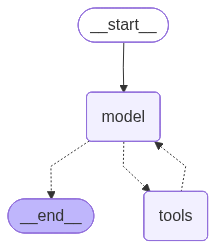

In [ ]:
from langchain.messages import ToolMessage
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call

@wrap_tool_call # 工具调用的时候
def handle_tool_error(
    request: ModelRequest, 
    handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """通过自定义函数处理工具调用错误信息"""
    # 先直接往后用handler传递，然后try-except来捕获
    try:
        # 直接向后传递
        return handler(request)
    except Exception as e:
        # 自定义处理
        # return一个ToolMessage
        return ToolMessage(
            content=f"Tool error: Please check your input and try again. ({str(e)})",
            tool_call_id=request.tool_call["id"]
        )

agent = create_agent(
    model=model,
    tools=[calculate_tip], # 没注入Tools，还不能写中间件，会报错
    middleware=[handle_tool_error]
)
agent

【思考🤔】我如果不想我的所有Tools都要经过一遍中间件怎么办，有一些比较简单的执行过程可以不用定义中间件



1. 创建不同层级的Agent，一些简单任务就可以给简单的Agent执行，然后就不用注入中间件

2. 在hook内部添加条件判断，根据状态、上下文或自定义标志决定是否执行逻辑

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable

@wrap_model_call
def conditional_middleware(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """根据状态中的标志决定是否执行hook逻辑"""
    
    # 方法1：检查状态中的跳过标志
    skip_hooks = request.state.get("skip_hooks", False)
    if skip_hooks:
        # 直接传递，不执行任何过滤逻辑
        return handler(request)
    
    # 方法2：根据工具类型跳过
    tool_name = None
    if request.tool_call:
        tool_name = request.tool_call.get("name")
    
    # 如果是特定工具，跳过过滤
    if tool_name in ["simple_tool", "public_tool"]:
        return handler(request)
    
    # 方法3：根据对话阶段
    message_count = len(request.state["messages"])
    if message_count < 3:  # 对话初期跳过复杂逻辑
        return handler(request)
    
    # 正常执行hook逻辑（例如工具过滤）
    # ... 您的过滤逻辑 ...
    modified_request = request
    
    return handler(modified_request)



3. 使用Runtime上下文控制，通过runtime.context传递控制标志

In [ ]:
from dataclasses import dataclass

@dataclass
class Context: # 上下文
    user_id: str
    skip_hooks: bool = False  # 添加控制标志

@wrap_model_call
def context_aware_middleware(request, handler):
    """根据runtime.context决定是否执行"""
    if (request.runtime and request.runtime.context and 
        request.runtime.context.skip_hooks):
        return handler(request)
    
    # 正常执行hook逻辑
    # ...
    # print("执行了hooks")
    modified_request = request
    return handler(modified_request)

# 调用时控制
result = agent.invoke({
    "messages": [{"role": "user", "content": "Hello"}],
}, runtime={
    "context": Context(user_id="user123", skip_hooks=True)  # 跳过hooks
})

result

{'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='36a04da1-409a-4217-9800-f01bd46d707b'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 191, 'total_tokens': 200, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': '', 'id': '019cd184c54ebb4151e8bb5880e84fb9', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cd184-c5b5-78e3-b6cc-23e96046a263-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 191, 'output_tokens': 9, 'total_tokens': 200, 'input_token_details': {}, 'output_token_details': {'reasoning': 0}})]}

## System Prompt 系统提示词
一般的写死的系统提示词就不说了，langchian中可以通过 `@dynamci_prompt` 装饰器创建中间件，该中间件根据模型请求生成系统提示

In [25]:
from pydantic import BaseModel
from typing import TypedDict

from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest

# 只支持TypedDict，不支持Pydantic的BaseModel
class Context(TypedDict):
    user_role: str # 用户角色

@dynamic_prompt # 应该是before_model的
def user_role_prompt(request: ModelRequest) -> str:
    """Generate system prompt based on user role."""
    user_role = request.runtime.context.get("user_role", "user")
    base_prompt = "You are a helpful assistant."

    # 其实也是提前写好几个提示词模板，然后根据上下文的参数来改动一下
    if user_role == "expert":
        return f"{base_prompt} Provide detailed technical responses."
    elif user_role == "beginner":
        return f"{base_prompt} Explain concepts simply and avoid jargon."

    return base_prompt

agent = create_agent(
    model=model,
    middleware=[user_role_prompt],
    tools=[],
    context_schema=Context,
)
result = agent.invoke(
    {"messages": 
        [{"role": "user", "content": "Explain machine learning"}]},
    context={"user_role": "expert"}
)
print(result)
# content 是内容；context是上下文


{'messages': [HumanMessage(content='Explain machine learning', additional_kwargs={}, response_metadata={}, id='794af2ca-6c6c-4be2-962a-607c6f732689'), AIMessage(content="Machine learning is a subset of artificial intelligence (AI) that involves the development of algorithms and statistical models that enable computer systems to perform tasks without explicit programming. The core idea is to allow computers to learn from data, identify patterns, and make decisions or predictions based on that learning, without being explicitly programmed to perform the task.\n\n### Key Concepts in Machine Learning\n\n1. **Supervised Learning:**\n   - **Definition:** In supervised learning, the algorithm is trained on a labeled dataset, where each data point is associated with a label or output. The goal is to learn a mapping from inputs to outputs.\n   - **Examples:** Predicting house prices based on features like size, location, and age of the house; classifying emails as spam or not spam.\n   - **Type

In [26]:
print(result['messages'][-1].content)

Machine learning is a subset of artificial intelligence (AI) that involves the development of algorithms and statistical models that enable computer systems to perform tasks without explicit programming. The core idea is to allow computers to learn from data, identify patterns, and make decisions or predictions based on that learning, without being explicitly programmed to perform the task.

### Key Concepts in Machine Learning

1. **Supervised Learning:**
   - **Definition:** In supervised learning, the algorithm is trained on a labeled dataset, where each data point is associated with a label or output. The goal is to learn a mapping from inputs to outputs.
   - **Examples:** Predicting house prices based on features like size, location, and age of the house; classifying emails as spam or not spam.
   - **Types of Models:** Linear regression, logistic regression, support vector machines (SVMs), decision trees, random forests, and neural networks.

2. **Unsupervised Learning:**
   - *

### name -- Agent名称
可以设置name，在mulit-Agent系统中，用作节点的标识符

不要用驼峰，要用下划线

推荐使用 snake_case 作为代理名称（例如， research_assistant 而不是 Research Assistant ）。一些模型提供商会拒绝包含空格或特殊字符的名称并报错。仅使用字母数字字符、下划线和连字符可以确保与所有提供者的兼容性。工具名称也适用相同规则。

# 高级概念

## 结构化输出
在某些情况下，您可能希望代理以特定格式返回输出。LangChain 通过 `response_format` 参数提供了结构化输出的策略。

### ToolStrategy
通过Pydantic、TypedDict、dataclass来定义数据格式

ToolStrategy 使用人工工具调用生成结构化输出，适合任何支持工具调用的模型来实现结构化输出

In [27]:
from pydantic import BaseModel
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# 自定义结构化输出格式（schema）
class ContactInfo(BaseModel):
    name: str
    email: str
    phone: str
    
agent = create_agent(
    model=model,
    tools=[calculate_tip],
    response_format=ToolStrategy(ContactInfo)
)

result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"
        }]
})

result

{'messages': [HumanMessage(content='Extract contact info from: John Doe, john@example.com, (555) 123-4567', additional_kwargs={}, response_metadata={}, id='ea41c925-fab4-4562-9d71-0f8d62c393c1'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 293, 'total_tokens': 350, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': '', 'id': '019cd1afe650ffd44fff4352d25bb2f4', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cd1af-e68b-7ef3-995e-bfedb6e94d63-0', tool_calls=[{'name': 'ContactInfo', 'args': {'name': 'John Doe', 'email': 'john@example.com', 'phone': '(555) 123-4567'}, 'id': '019cd1afee0503f2ef5ca69fc9d9ff55', 'type': 'tool_call'}], invalid_tool_calls=[], usage_met

In [31]:
result['structured_response']

ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')

### ProviderStrategy
`ProviderStrategy` 使用`模型提供者`的`原生`结构化输出生成。这更可靠，但仅适用于支持原生结构化输出的提供者

`【Tips】`

`response_format`可以不指定结构化输出的实现类，如果模型支持原生的结构化输出就直接用，如果不支持就退回`ToolStrategy`

In [ ]:
agent = create_agent(
    model=model,
    tools=[calculate_tip],
    response_format=ContactInfo # 只需要传入schema
)

## Memory 记忆
智能体通过消息状态自动维护对话历史。您还可以配置智能体使用自定义状态模式，在对话过程中记住额外信息。

存储在state中的info可以被视为 Agent的短期记忆

> ⚠️自定义的状态结构只能使用 `TypedDict` 的形式去**扩展** `AgentState`

AgentState默认只有三种
- messages
- jump_to
- structured_response


，可以通过继承和state

### 两种自定义状态的方式

1. 通过中间件实现 -- 推荐

In [ ]:
from langchain.agents import AgentState, create_agent
from langchain.agents.middleware import AgentMiddleware
from langchain.tools import tool
from typing import Any
import os
from langchain_openai import ChatOpenAI

# 定义小费计算工具（如果尚未定义）
@tool
def calculate_tip(bill_amount: float, tip_percentage: float = 20.0) -> str:
    """从账单中计算小费"""
    tip = bill_amount * (tip_percentage / 100)
    return f"Tip: ${tip:.2f}, Total: ${bill_amount + tip:.2f}"

# 获取模型实例
def get_model():
    """获取聊天模型实例"""
    return ChatOpenAI(
        model="Qwen/Qwen2.5-7B-Instruct",
        base_url="https://api.siliconflow.cn/v1",
        api_key=os.environ.get("SILICONFLOW_API_KEY"),
        temperature=0.2,
    )

model = get_model()

# 继承扩展AgentState
class CustomState(AgentState):
    user_preferences: dict  # 【用户偏好】字典


class CustomMiddleware(AgentMiddleware[CustomState]):
    state_schema = CustomState
    tools = [calculate_tip]

    def before_model(self, state: CustomState, runtime) -> dict[str, Any] | None:
        """
        在模型调用前执行，可以根据用户偏好调整行为
        
        参数:
            state: 包含消息和用户偏好的自定义状态
            runtime: 运行时上下文
            
        返回:
            None: 继续正常执行
            dict: 更新状态或跳转到其他节点
        """
        # 获取用户偏好，默认为空字典
        preferences = state.get("user_preferences", {})
        
        # 示例1: 记录模型调用次数
        call_count = preferences.get("model_call_count", 0)
        call_count += 1
        preferences["model_call_count"] = call_count
        
        # 示例2: 如果调用次数过多，提前结束
        if call_count > 3:  # 设置为3次以便演示
            return {
                "messages": [{
                    "role": "assistant", 
                    "content": f"已达到最大调用次数({call_count})，对话结束。您偏好{preferences.get('style', '默认')}风格。"
                }],
                "jump_to": "end" # langgraph 的 end
            }
        
        # 示例3: 根据用户偏好风格调整行为
        style = preferences.get("style", "balanced")
        verbosity = preferences.get("verbosity", "normal")
        
        # 可以根据偏好修改状态或添加提示
        # 这里演示如何基于偏好添加系统消息
        if style == "technical" and verbosity == "detailed":
            # 在实际应用中，可以通过dynamic_prompt中间件添加系统提示
            # 这里仅记录到偏好中
            preferences["last_adjustment"] = "applied_technical_detailed"
        elif style == "simple":
            preferences["last_adjustment"] = "applied_simple"
        
        # 返回更新后的用户偏好（会自动合并到状态中）
        return {"user_preferences": preferences}
    
# 创建带有自定义中间件的Agent
agent = create_agent(
    model,
    tools=[calculate_tip],
    middleware=[CustomMiddleware()]
)

# 测试1: 带有技术性偏好的用户
print("=== 测试1: 技术性偏好用户 ===")
result1 = agent.invoke({
    "messages": [{"role": "user", "content": "计算100美元账单的20%小费"}],
    "user_preferences": {"style": "technical", "verbosity": "detailed"},
})
print("结果:", result1.get("messages", [])[-1].content if result1.get("messages") else result1)
print("最终状态中的偏好:", result1.get("user_preferences", {}))

# 测试2: 简单偏好用户，多次调用以触发限制
print("\n=== 测试2: 简单偏好用户，多次调用 ===")
# 第一次调用
result2 = agent.invoke({
    "messages": [{"role": "user", "content": "你好"}],
    "user_preferences": {"style": "simple", "model_call_count": 2},  # 从2开始，下次会触发限制
})
print("第二次调用结果:", result2.get("messages", [])[-1].content if result2.get("messages") else result2)
print("最终状态:", {k: v for k, v in result2.items() if k != "messages"})

=== 测试1: 技术性偏好用户 ===
结果: 对于100美元的账单，20%的小费是20.00美元，总计是120.00美元。
最终状态中的偏好: {'style': 'technical', 'verbosity': 'detailed', 'model_call_count': 2, 'last_adjustment': 'applied_technical_detailed'}

=== 测试2: 简单偏好用户，多次调用 ===
第二次调用结果: 如果需要，您可以直接提出您的需求，我会尽力帮助您。如果有更多对话，请重新开始聊天。
最终状态: {'user_preferences': {'style': 'simple', 'model_call_count': 4}}


2. 通过create_agent 的 state_schema 上定义
 

### 2. 通过create_agent的state_schema参数定义自定义状态

除了通过中间件定义自定义状态，还可以直接在`create_agent`函数中使用`state_schema`参数。这种方式适合那些不需要中间件逻辑，但需要扩展状态的简单场景。

**注意**：官方推荐使用中间件方式，因为这样可以将状态扩展与相关的中间件和工具逻辑封装在一起，更符合关注点分离原则。`state_schema`参数主要为了向后兼容。

In [ ]:
from typing import TypedDict, NotRequired
from langchain.agents import create_agent, AgentState

# 通过TypedDict扩展AgentState
class ExtendedState(AgentState):
    """通过TypedDict扩展的自定义状态"""
    user_id: NotRequired[str]  # 用户ID，可选字段
    session_data: NotRequired[dict]  # 会话数据
    call_counter: NotRequired[int]  # 调用计数器

# 创建Agent时直接指定state_schema
agent_with_schema = create_agent(
    model,
    tools=[calculate_tip],
    state_schema=ExtendedState  # 直接传入状态schema
)

# 调用时传入自定义状态字段
print("=== 使用state_schema定义自定义状态 ===")
result = agent_with_schema.invoke({
    "messages": [{"role": "user", "content": "计算50美元账单的15%小费"}],
    "user_id": "user_12345",
    "session_data": {"theme": "dark", "language": "zh"},
    "call_counter": 1
})

print("模型响应:", result.get("messages", [])[-1].content if result.get("messages") else "无消息")
print("返回的状态字段:")
for key in ["user_id", "session_data", "call_counter"]:
    if key in result:
        print(f"  {key}: {result[key]}")

# 注意：通过state_schema定义的状态字段会被保留在结果中
print("\n完整结果键:", list(result.keys()))

# 完整结果键: ['messages', 'user_id', 'session_data', 'call_counter']
# messages 是本身必须的参数

=== 使用state_schema定义自定义状态 ===
模型响应: 对于50美元的账单，15%的小费是7.50美元，因此总金额是57.50美元。
返回的状态字段:
  user_id: user_12345
  session_data: {'theme': 'dark', 'language': 'zh'}
  call_counter: 1

完整结果键: ['messages', 'user_id', 'session_data', 'call_counter']


## Streaming 流式输出
一般 `invoke` 是调用一次，它会等所有的流程走完之后再一次性的返回结果，通过 `stream` 就可以展示中间过程，流式输出



In [43]:
from langchain.messages import AIMessage, HumanMessage
agent = create_agent(
    model=get_model(),
    tools=[calculate_tip]
)
for chunk in agent.stream(
    {"messages": HumanMessage(content="20%的消费计算19989894838429￥是多少?")}, 
    stream_mode='values'
):
    latest_message = chunk["messages"][-1]
    if latest_message.content:
        # 如果有内容
        if isinstance(latest_message, HumanMessage):
            print(f"User: {latest_message.content}")
        elif isinstance(latest_message, AIMessage):
            print(f"Agent: {latest_message.content}")
    elif latest_message.tool_calls:
        print(f"Calling tools: {[tc['name'] for tc in latest_message.tool_calls]}")

User: 20%的消费计算19989894838429￥是多少?
Calling tools: ['calculate_tip']
Agent: 根据20%的小费计算，19989894838429￥的小费是3997978967685.80￥，总计是23987873806114.80￥。
